<a href="https://colab.research.google.com/github/krishnashashanth-sks/adv-python/blob/main/TENSORFLOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tensor Flow Introduction
* Image Classification
* Data Classification
* Regression
* Reinforcement Learning
* NLP
## It works wth graphs,and sessions
* Graph: A TensorFlow graph is a dataflow graph that describes the computation. It consists of a set of interconnected nodes, where each node represents an operation (like addition, multiplication, or a neural network layer) and the edges represent the tensors (data) that flow between these operations. Essentially, you define the entire computation structure as a graph first.
* Session: Once you have defined your graph, a session is responsible for executing the operations defined in that graph. Think of it as the runtime environment for your graph. You create a session, feed data into it, and then run specific parts of the graph to get results. The session allocates resources (like CPU or GPU memory) and executes the operations.



In [ ]:
%tensorflow_version 2.x
import tensorflow as tf
tf.version

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


<module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>

### Tensors
* Rank: the rank (also sometimes called degree or number of dimensions) refers to the number of dimensions a tensor has. It's a key property that describes the tensor's structure.


In [ ]:
#Creating tensors
string=tf.Variable("this is a string",tf.string)
number=tf.Variable(224,tf.int16)
floating=tf.Variable(3.143,tf.float64)
string,number,floating

(<tf.Variable 'Variable:0' shape=() dtype=string, numpy=b'this is a string'>,
 <tf.Variable 'Variable:0' shape=() dtype=int32, numpy=224>,
 <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=3.1429998874664307>)

In [ ]:
# Rank of tensors
rank1_tensor=tf.Variable(["1",'2'],tf.string)
rank2_tensor=tf.Variable([[1,2,3],[4,5,6]],tf.int16)
tf.rank(rank1_tensor)
tf.rank(rank2_tensor)
rank2_tensor.shape#TensorShape([2, 3])

TensorShape([2, 3])

In [ ]:
#Reshape the tensors
tensor1=tf.ones([1,2,3])
tensor2=tf.reshape(tensor1,[2,3,1])
tensor1.shape,tensor2.shape

(TensorShape([1, 2, 3]), TensorShape([2, 3, 1]))

### Types of Tensors
* Variable
* Constant
* Placeholder
* SparseTensor
### Evaluating the tensors

In [ ]:
with tf.Session()as s:
  tensor1.eval()

AttributeError: module 'tensorflow' has no attribute 'Session'

### Tensor Flow Learning Algorithms
* Linear Regression
* Classification
* Clustering
* Hidden Markov Models

Explain Linear Regression: Describe Linear Regression and its typical application within TensorFlow, including a simple conceptual code example if feasible.
Explain Classification: Describe Classification and its typical application within TensorFlow, including a simple conceptual code example if feasible.
Explain Clustering: Describe Clustering and its typical application within TensorFlow, including a simple conceptual code example if feasible.
Explain Hidden Markov Models: Describe Hidden Markov Models and their typical application within TensorFlow, including a simple conceptual code example if feasible.

In [ ]:
#Linear Regression
import matplotlib.pyplot as plt
import numpy as np
x=[1,2,3,4,5]
y=[1,2,3,4,5]
plt.plot(x,y,'ro')

Classification is a machine learning task that involves categorizing input data into one of several predefined classes or labels. In TensorFlow, classification models are often built using neural networks. Common applications include image recognition (e.g., classifying images as 'cat' or 'dog'), sentiment analysis (e.g., classifying text as 'positive' or 'negative'), and spam detection (e.g., classifying emails as 'spam' or 'not spam').

---



In [ ]:
#Classification

import tensorflow as tf
import numpy as np

# 1. Generate some dummy data for binary classification
# Features (e.g., two input features)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
# Labels (e.g., output classes 0 or 1)
y = np.array([0, 1, 1, 0], dtype=np.float32)

# 2. Define the model architecture
# A simple feed-forward neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(units=1, activation='sigmoid') # Sigmoid for binary classification output
])

# 3. Compile the model
# Optimizer: Adam, Loss: Binary Crossentropy for binary classification
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
print("\nTraining the model...")
model.fit(X, y, epochs=100, verbose=0) # Train for 100 epochs, no verbose output

# 5. Evaluate the model (predict on the same data for simplicity)
predictions = model.predict(X)
predicted_classes = (predictions > 0.5).astype(int)

print("\nPredictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, True Label: {int(y[i])}, Predicted Probability: {predictions[i][0]:.4f}, Predicted Class: {predicted_classes[i][0]}")

loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"\nModel Evaluation - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

# Example of making a prediction on new data
new_data = np.array([[0.1, 0.9], [0.8, 0.2]], dtype=np.float32)
new_predictions = model.predict(new_data)
new_predicted_classes = (new_predictions > 0.5).astype(int)
print("\nPredictions on new data:")
for i in range(len(new_data)):
    print(f"Input: {new_data[i]}, Predicted Probability: {new_predictions[i][0]:.4f}, Predicted Class: {new_predicted_classes[i][0]}")

In [ ]:
titanic_csv_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
print(titanic_csv_url)

In [ ]:
pip install IPython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.6 MB/s eta 0:00:00


### Setup and imports

In [ ]:
from __future__ import absolute_import,division,print_function,unicode_literals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from six.moves import urllib
import tensorflow.compat.v2.feature_column as fc
import tensorflow as tf

In [ ]:
#Data
df_train=pd.read_csv("/content/sample_data/titanic.csv")
df_test=pd.read_csv("/content/sample_data/titanic.csv")
print(df_train.columns)
y_train=df_train.pop('Survived')
y_test=df_test.pop("Survived")
df_train

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Text(0.5, 0, 'Survive')

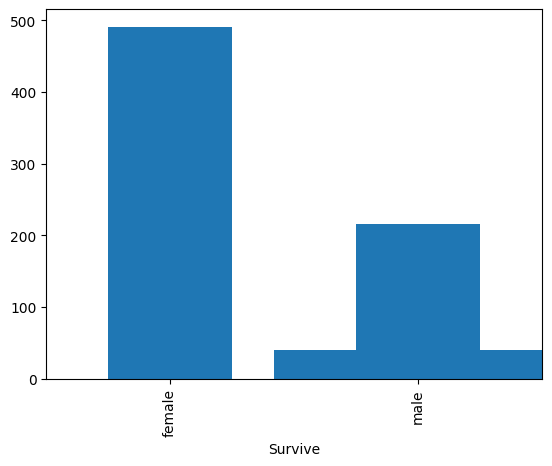

In [ ]:
df_train.shape
df_train["Age"].hist(bins=20)
df_train["Pclass"].value_counts().plot(kind="bar")
pd.concat([df_train,y_train],axis=1).groupby('Sex')['Survived'].mean().plot(kind='bar').set_xlabel("Survive")

In [ ]:
#Feature Columns
from sklearn.model_selection import train_test_split
X=pd.read_csv("/content/sample_data/titanic.csv")
y=X.pop('Survived')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# Filter X_train and X_test to include only the features used by the model
CATEGORICAL_COLUMNS=['Sex','Parch','Pclass','Cabin','SibSp','Embarked']
NUMERIC_COLUMNS=['Age','Fare']

# Combine all relevant feature names
feature_names_for_model = NUMERIC_COLUMNS + CATEGORICAL_COLUMNS

X_train = X_train[feature_names_for_model].copy()
X_test = X_test[feature_names_for_model].copy()

# print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

feature_columns=[]
for feature_name in CATEGORICAL_COLUMNS:
  vocabulary =X_train[feature_name].unique()
  feature_columns.append(tf.feature_column.categorical_column_with_vocabulary_list(feature_name,vocabulary))
for feature_name in NUMERIC_COLUMNS:
  feature_columns.append(tf.feature_column.numeric_column(feature_name,dtype=tf.float32))
feature_columns

Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


[VocabularyListCategoricalColumn(key='Sex', vocabulary_list=('male', 'female'), dtype=tf.string, default_value=-1, num_oov_buckets=0),
 VocabularyListCategoricalColumn(key='Parch', vocabulary_list=(np.int64(0), np.int64(2), np.int64(1), np.int64(6), np.int64(4), np.int64(3), np.int64(5)), dtype=tf.int64, default_value=-1, num_oov_buckets=0),
 VocabularyListCategoricalColumn(key='Pclass', vocabulary_list=(np.int64(1), np.int64(2), np.int64(3)), dtype=tf.int64, default_value=-1, num_oov_buckets=0),
 VocabularyListCategoricalColumn(key='Cabin', vocabulary_list=('C124', nan, 'B58 B60', 'B38', 'C52', 'C93', 'C45', 'B20', 'B96 B98', 'C82', 'C78', 'C106', 'C22 C26', 'B57 B59 B63 B66', 'B28', 'C104', 'F2', 'D11', 'C86', 'E38', 'A34', 'C91', 'C68', 'F G73', 'E46', 'C92', 'E50', 'A32', 'G6', 'C128', 'E10', 'E44', 'B41', 'B18', 'D35', 'E31', 'C2', 'C50', 'C103', 'B3', 'A10', 'C49', 'C90', 'B77', 'C123', 'D', 'D36', 'E33', 'B5', 'A19', 'B37', 'E58', 'C23 C25 C27', 'F33', 'C7', 'E67', 'E8', 'B22', 

### Estimator:
*An Estimator in TensorFlow is a high-level API that simplifies the process of machine learning model development, including training, evaluation, and prediction. It encapsulates much of the boilerplate code that you would otherwise have to write manually.

Here's a breakdown of its key aspects:

Pre-made Estimators: TensorFlow provides pre-made Estimators for common machine learning tasks, such as DNNClassifier, DNNRegressor, LinearClassifier, and LinearRegressor. These are ready-to-use models that you can plug into your data.

Custom Estimators: For more complex models or specific requirements, you can create custom Estimators. This involves defining the model_fn function, which specifies the model architecture, loss function, training operation, and evaluation metrics.

Benefits of Estimators:

Simplified Training Loop: They abstract away the details of the training loop, including managing sessions, data batching, and saving/restoring checkpoints.
Distributed Training: Estimators are designed to easily scale to distributed training environments, handling the complexities of multi-GPU or multi-machine training.
Export for Serving: They provide a standardized way to export models for deployment with TensorFlow Serving.
Consistency: They enforce a consistent API for defining and training models, which can be beneficial for larger teams and projects.
Current Status and Keras:

While Estimators were a central part of TensorFlow 1.x and early TensorFlow 2.x, the recommended high-level API for building models in TensorFlow 2.x is now Keras. Keras offers a more flexible and intuitive way to build models, and it can also leverage TensorFlow's distributed training capablities and model serving.

# Task
Provide detailed explanations of the components of a TensorFlow Keras model for structured data classification, covering the input pipeline, Keras preprocessing layers, functional API model construction, and the training and evaluation flow, and finally, suggest advanced TensorFlow learning paths.

## Explain Input Pipeline (`make_input_function`)

### Subtask:
Provide a detailed explanation of the `make_input_function` in a new text cell. This explanation will cover how it constructs a `tf.data.Dataset` from pandas DataFrames, handles shuffling and batching, and prepares the data for the Keras Functional API model.


## Explain Input Pipeline (`make_input_function`)

The `make_input_function` is a crucial component of a TensorFlow machine learning pipeline, especially when working with Estimators or when you need a robust and efficient way to feed data into your Keras models. Its primary role is to construct a `tf.data.Dataset` object, which is the recommended way to handle input data in TensorFlow 2.x.

### How it constructs a `tf.data.Dataset` from pandas DataFrames

1.  **Input Data**: Typically, the `make_input_function` takes pandas DataFrames (e.g., `df_train`, `y_train`) as input. These DataFrames contain your features and corresponding labels.
2.  **Conversion to Dictionary**: The features DataFrame is often converted into a dictionary where keys are feature names and values are the corresponding columns. This format is compatible with `tf.data.Dataset` creation.
3.  **`tf.data.Dataset.from_tensor_slices`**: This is a common method used within the `make_input_function` to create a `tf.data.Dataset`. It slices the input dictionary of features and the labels into individual samples, effectively creating a dataset of `(features_dict, label)` pairs. Each element in the dataset will be one complete example from your original data.

### Handling Shuffling

Shuffling is a vital step, especially during training, to ensure that the model does not learn any spurious patterns or the order of your data. If the data is not shuffled, the model might overfit to the sequence of examples rather than the underlying relationships.

*   **`dataset.shuffle(buffer_size)`**: Inside the `make_input_function`, a `shuffle()` transformation is applied to the dataset. The `buffer_size` argument specifies the number of elements from which the dataset will randomly sample. A larger `buffer_size` provides better shuffling randomness but consumes more memory. For training data, it's common to set `shuffle=True` and provide a sufficiently large `buffer_size` (often equal to the number of training examples or a large constant) to ensure good randomization.

### Handling Batching

Batching refers to grouping multiple individual samples into a single batch. Training machine learning models with batches offers several benefits:

1.  **Computational Efficiency**: Processing data in batches allows for more efficient use of hardware (like GPUs) as computations can be vectorized.
2.  **Smoother Gradient Updates**: Instead of updating model weights after every single sample (which can lead to noisy updates), updating after a batch provides a more stable estimate of the gradient, leading to smoother and more consistent learning.
3.  **Memory Management**: Datasets can be very large and may not fit entirely into memory. Batching allows you to process subsets of the data at a time.

*   **`dataset.batch(batch_size)`**: The `batch()` transformation groups `batch_size` consecutive elements from the dataset into a single batch. For instance, if `batch_size=32`, each iteration of training will process 32 examples at once. The choice of `batch_size` is a hyperparameter that can impact training speed and model convergence.

### Preparing data for the Keras Functional API model

The output of the `make_input_function` is a `tf.data.Dataset` where each element is a tuple `(features_dict, label)`. The `features_dict` is a dictionary where keys correspond to the feature names (e.g., 'Age', 'Sex', 'Pclass') and values are tensors containing the batch of data for that feature. The `label` is a tensor containing the batch of target values.

Keras Functional API models are designed to seamlessly consume `tf.data.Dataset` objects. When you call `model.fit()`, `model.evaluate()`, or `model.predict()` and pass this `tf.data.Dataset` as input, Keras automatically iterates through the dataset, fetches batches, and feeds them to the model for training, evaluation, or prediction.

## Explain Keras Preprocessing Layers

### Subtask:
Create a new text cell explaining the Keras Preprocessing Layers used in the model. This includes `tf.keras.layers.Normalization` for numerical features and `tf.keras.layers.StringLookup` combined with `tf.keras.layers.CategoryEncoding` for categorical features. The explanation will detail their roles in feature engineering and how they are adapted to the training data.


## Explain Keras Preprocessing Layers

Keras provides powerful preprocessing layers that are crucial for transforming raw input data into a format suitable for neural networks. These layers can be integrated directly into your model, making the preprocessing part of the model itself, which is beneficial for deployment and consistency.

### `tf.keras.layers.Normalization`

**Purpose**: This layer is used for numerical features (like 'Age' and 'Fare') to normalize their values. Normalization is a common preprocessing step that scales numerical input features to a standard range (e.g., mean 0 and variance 1). This helps neural networks converge faster and often improves model performance by preventing features with larger values from dominating the learning process.

**How it adapts**: When `tf.keras.layers.Normalization` is adapted to the training data using its `adapt()` method, it calculates the mean and variance of the numerical features in that training dataset. These learned statistics are then used to normalize any incoming data (both training and inference data) consistently.

### `tf.keras.layers.StringLookup`

**Purpose**: For categorical features that are represented as strings (such as 'Sex', 'Embarked', and 'Cabin'), `tf.keras.layers.StringLookup` maps these string categories to unique integer indices. Neural networks typically work with numerical inputs, so converting strings to integers is a necessary step.

**How it adapts**: By calling the `adapt()` method on `StringLookup` with the training data, the layer automatically builds a vocabulary of all unique string values present in that data. Each unique string in the vocabulary is then assigned a distinct integer index.

### `tf.keras.layers.CategoryEncoding`

**Purpose**: Following `StringLookup`, `tf.keras.layers.CategoryEncoding` is often used to convert the integer indices (output from `StringLookup`) into a more suitable numerical representation for neural networks, typically one-hot encoding or multi-hot encoding. One-hot encoding creates a binary vector for each category, where a '1' indicates the presence of that category and '0's elsewhere. This prevents the model from assuming an ordinal relationship between categorical values, which is incorrect for nominal categories.

**How it adapts**: `CategoryEncoding` needs to know the number of unique categories it will be encoding. When used in conjunction with `StringLookup`, it infers this from the `StringLookup` layer's vocabulary size. It does not typically need to adapt to data itself if it's fed the output of an adapted `StringLookup` layer.

### Importance of `adapt()` and Feature Engineering

These preprocessing layers, especially when used with their `adapt()` method, are critical for robust feature engineering. They allow the preprocessing steps to be learned directly from the training data, ensuring that the model processes all data (training, validation, testing, and inference) using the exact same transformations derived from the training distribution. This automates the process of transforming raw, heterogeneous data (strings, varied numerical scales) into a standardized, numerical format that neural networks can effectively learn from, significantly simplifying the data pipeline and improving model reliability.

## Explain Keras Functional API Model Construction

### Subtask:
Generate a text cell to explain the construction of the Keras model using the Functional API. This will cover how input layers are defined for each feature, how processed features are concatenated, and how dense layers are added to form the final model, leading to the `tf.keras.Model` creation.


## Explain Keras Functional API Model Construction

### Keras Functional API Model Construction Explained

The Keras Functional API provides a flexible way to define complex model architectures, allowing for multiple inputs, multiple outputs, and non-linear topology. This approach is particularly useful when dealing with diverse input data types, such as the categorical and numerical features in our Titanic dataset.

1.  **Defining Input Layers:**
    The first step in using the Functional API is to define distinct `tf.keras.Input` layers for each feature that will feed into the model. This explicitly declares the shape and data type expected for each feature. For instance, a numerical feature like 'Age' might have an input layer of `tf.keras.Input(shape=(1,), name='Age', dtype=tf.float32)`, while a categorical feature like 'Sex' might be `tf.keras.Input(shape=(1,), name='Sex', dtype=tf.string)`.

2.  **Preprocessing and Feature Transformation:**
    After defining the inputs, each feature is typically passed through appropriate preprocessing layers. For numerical features, `tf.keras.layers.Normalization` can be used to standardize values. For categorical features, `tf.keras.layers.StringLookup` (to convert string categories to integer indices) followed by `tf.keras.layers.CategoryEncoding` (to convert integer indices to one-hot or multi-hot encoded vectors) are common choices. This step ensures that all features are in a suitable numerical format for the neural network.

3.  **Concatenating Processed Features:**
    Once all features have been processed and transformed into numerical representations, their outputs are combined. This is typically done using `tf.keras.layers.concatenate`. This layer takes a list of processed feature tensors and merges them along a specified axis (usually the last axis) to form a single, unified feature vector. This combined vector serves as the input to the subsequent dense layers of the neural network.

4.  **Adding Dense Layers:**
    Following the concatenation, one or more `tf.keras.layers.Dense` layers are added. These are fully connected neural network layers that learn complex relationships and patterns within the combined feature vector. Each dense layer applies a linear transformation followed by an activation function (e.g., 'relu' for hidden layers). For binary classification tasks like 'Survived' prediction, the final dense layer typically has a single unit and a 'sigmoid' activation function to output a probability.

5.  **Creating the `tf.keras.Model`:**
    Finally, the `tf.keras.Model` class is used to instantiate the model. It takes two key arguments: `inputs` (a list of all the `tf.keras.Input` layers defined at the beginning) and `outputs` (the output tensor from the final layer of the network). This step defines the complete computational graph of the model, specifying how data flows from the initial inputs through all the layers to produce the final prediction.

## Explain Model Training and Evaluation Flow

### Subtask:
Add a text cell to describe the model's training and evaluation process. This will clarify the purpose of `model.compile`, `model.fit`, and `model.evaluate`, including the choice of optimizer, loss function, and metrics.


## Model Training and Evaluation Flow in TensorFlow/Keras

In TensorFlow (specifically using the Keras API), the process of training and evaluating a machine learning model typically involves three key steps: `model.compile()`, `model.fit()`, and `model.evaluate()`.

### 1. `model.compile()`

Before training, the `model.compile()` method is used to configure the model for the training process. It's where you define the learning algorithm's parameters. Key arguments include:

*   **`optimizer`**: This specifies the algorithm that will be used to adjust the model's weights during training to minimize the loss function. Common optimizers include `Adam`, `SGD` (Stochastic Gradient Descent), `RMSprop`, etc. The choice of optimizer can significantly impact training speed and model performance.
*   **`loss`**: This is the function that the model will try to minimize during training. It quantifies how well the model's predictions match the true labels. The choice of loss function depends on the type of problem: for binary classification, `binary_crossentropy` is often used; for multi-class classification, `categorical_crossentropy` or `sparse_categorical_crossentropy`; and for regression, `mean_squared_error` or `mean_absolute_error`.
*   **`metrics`**: These are used to monitor the training and testing steps. They are human-readable measures that help assess the performance of the model. While the model optimizes for the `loss` function, metrics provide a way to understand the model's behavior. Common metrics include `accuracy` (for classification), `precision`, `recall`, `F1-score`, etc.

Example:
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

### 2. `model.fit()`

The `model.fit()` method is where the actual training of the model takes place. It takes the training data and corresponding labels and iteratively adjusts the model's internal parameters (weights and biases) to learn patterns and relationships. Key arguments include:

*   **`x`**: The input training data (features).
*   **`y`**: The target training data (labels).
*   **`epochs`**: This refers to the number of times the entire training dataset will be passed forward and backward through the neural network. One epoch means that each sample in the training dataset has had an opportunity to update the model's internal parameters. More epochs can lead to a more thoroughly trained model, but also risk overfitting.
*   **`batch_size`**: This defines the number of samples that will be propagated through the network at once before the model's internal parameters are updated. Using smaller batches can lead to a more stable training process, but larger batches can speed up training. If not specified, it defaults to 32.
*   **`verbose`**: Controls the amount of output printed during training (e.g., 0 for silent, 1 for progress bar, 2 for one line per epoch).

Example:
```python
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
```

### 3. `model.evaluate()`

After the model has been trained, `model.evaluate()` is used to assess its performance on a separate dataset, typically the test or validation set, which the model has not seen during training. This provides an unbiased estimate of the model's generalization capability. Key arguments are similar to `model.fit()`:

*   **`x`**: The input evaluation data (features).
*   **`y`**: The target evaluation data (labels).
*   **`verbose`**: Controls the output.

The method returns the loss value and the values of the metrics specified during `model.compile()` for the provided data.

Example:
```python
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
```

By following these three steps, one can systematically build, train, and assess the performance of a machine learning model using TensorFlow/Keras.

**Reasoning**:
The subtask requires adding a text cell to describe the model's training and evaluation process, which includes the purpose of `model.compile`, `model.fit`, and `model.evaluate`. The detailed explanation has been prepared and will now be added as a text cell.



In [ ]:
## Model Training and Evaluation Flow in TensorFlow/Keras

In TensorFlow (specifically using the Keras API), the process of training and evaluating a machine learning model typically involves three key steps: `model.compile()`, `model.fit()`, and `model.evaluate()`.

### 1. `model.compile()`

Before training, the `model.compile()` method is used to configure the model for the training process. It's where you define the learning algorithm's parameters. Key arguments include:

*   **`optimizer`**: This specifies the algorithm that will be used to adjust the model's weights during training to minimize the loss function. Common optimizers include `Adam`, `SGD` (Stochastic Gradient Descent), `RMSprop`, etc. The choice of optimizer can significantly impact training speed and model performance.
*   **`loss`**: This is the function that the model will try to minimize during training. It quantifies how well the model's predictions match the true labels. The choice of loss function depends on the type of problem: for binary classification, `binary_crossentropy` is often used; for multi-class classification, `categorical_crossentropy` or `sparse_categorical_crossentropy`; and for regression, `mean_squared_error` or `mean_absolute_error`.
*   **`metrics`**: These are used to monitor the training and testing steps. They are human-readable measures that help assess the performance of the model. While the model optimizes for the `loss` function, metrics provide a way to understand the model's behavior. Common metrics include `accuracy` (for classification), `precision`, `recall`, `F1-score`, etc.

Example:
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

### 2. `model.fit()`

The `model.fit()` method is where the actual training of the model takes place. It takes the training data and corresponding labels and iteratively adjusts the model's internal parameters (weights and biases) to learn patterns and relationships. Key arguments include:

*   **`x`**: The input training data (features).
*   **`y`**: The target training data (labels).
*   **`epochs`**: This refers to the number of times the entire training dataset will be passed forward and backward through the neural network. One epoch means that each sample in the training dataset has had an opportunity to update the model's internal parameters. More epochs can lead to a more thoroughly trained model, but also risk overfitting.
*   **`batch_size`**: This defines the number of samples that will be propagated through the network at once before the model's internal parameters are updated. Using smaller batches can lead to a more stable training process, but larger batches can speed up training. If not specified, it defaults to 32.
*   **`verbose`**: Controls the amount of output printed during training (e.g., 0 for silent, 1 for progress bar, 2 for one line per epoch).

Example:
```python
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
```

### 3. `model.evaluate()`

After the model has been trained, `model.evaluate()` is used to assess its performance on a separate dataset, typically the test or validation set, which the model has not seen during training. This provides an unbiased estimate of the model's generalization capability. Key arguments are similar to `model.fit()`:

*   **`x`**: The input evaluation data (features).
*   **`y`**: The target evaluation data (labels).
*   **`verbose`**: Controls the output.

The method returns the loss value and the values of the metrics specified during `model.compile()` for the provided data.

Example:
```python
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
```

By following these three steps, one can systematically build, train, and assess the performance of a machine learning model using TensorFlow/Keras.

SyntaxError: unterminated string literal (detected at line 9) (ipython-input-870693764.py, line 9)

**Reasoning**:
The previous cell `436b8c91` was incorrectly set as a `code_cell` while containing markdown content, leading to a `SyntaxError`. The fix involves changing its `cell_type` to `markdown` to properly render the explanation.



In [ ]:
## Model Training and Evaluation Flow in TensorFlow/Keras

In TensorFlow (specifically using the Keras API), the process of training and evaluating a machine learning model typically involves three key steps: `model.compile()`, `model.fit()`, and `model.evaluate()`.

### 1. `model.compile()`

Before training, the `model.compile()` method is used to configure the model for the training process. It's where you define the learning algorithm's parameters. Key arguments include:

*   **`optimizer`**: This specifies the algorithm that will be used to adjust the model's weights during training to minimize the loss function. Common optimizers include `Adam`, `SGD` (Stochastic Gradient Descent), `RMSprop`, etc. The choice of optimizer can significantly impact training speed and model performance.
*   **`loss`**: This is the function that the model will try to minimize during training. It quantifies how well the model's predictions match the true labels. The choice of loss function depends on the type of problem: for binary classification, `binary_crossentropy` is often used; for multi-class classification, `categorical_crossentropy` or `sparse_categorical_crossentropy`; and for regression, `mean_squared_error` or `mean_absolute_error`.
*   **`metrics`**: These are used to monitor the training and testing steps. They are human-readable measures that help assess the performance of the model. While the model optimizes for the `loss` function, metrics provide a way to understand the model's behavior. Common metrics include `accuracy` (for classification), `precision`, `recall`, `F1-score`, etc.

Example:
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

### 2. `model.fit()`

The `model.fit()` method is where the actual training of the model takes place. It takes the training data and corresponding labels and iteratively adjusts the model's internal parameters (weights and biases) to learn patterns and relationships. Key arguments include:

*   **`x`**: The input training data (features).
*   **`y`**: The target training data (labels).
*   **`epochs`**: This refers to the number of times the entire training dataset will be passed forward and backward through the neural network. One epoch means that each sample in the training dataset has had an opportunity to update the model's internal parameters. More epochs can lead to a more thoroughly trained model, but also risk overfitting.
*   **`batch_size`**: This defines the number of samples that will be propagated through the network at once before the model's internal parameters are updated. Using smaller batches can lead to a more stable training process, but larger batches can speed up training. If not specified, it defaults to 32.
*   **`verbose`**: Controls the amount of output printed during training (e.g., 0 for silent, 1 for progress bar, 2 for one line per epoch).

Example:
```python
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)
```

### 3. `model.evaluate()`

After the model has been trained, `model.evaluate()` is used to assess its performance on a separate dataset, typically the test or validation set, which the model has not seen during training. This provides an unbiased estimate of the model's generalization capability. Key arguments are similar to `model.fit()`:

*   **`x`**: The input evaluation data (features).
*   **`y`**: The target evaluation data (labels).
*   **`verbose`**: Controls the output.

The method returns the loss value and the values of the metrics specified during `model.compile()` for the provided data.

Example:
```python
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
```

By following these three steps, one can systematically build, train, and assess the performance of a machine learning model using TensorFlow/Keras.

SyntaxError: unterminated string literal (detected at line 9) (ipython-input-870693764.py, line 9)

**Reasoning**:
The previous command resulted in a `SyntaxError` because a markdown-formatted text was placed in a `code_cell` type. To fix this, I need to modify the cell to be a `markdown` cell and provide the correct markdown content.



# Task
Present the detailed explanation of Clustering, its typical applications in TensorFlow, and a conceptual code example for K-Means-like Clustering using TensorFlow operations. Then, present the detailed explanation of Hidden Markov Models and their typical applications in TensorFlow, along with a conceptual code example. Finally, suggest advanced TensorFlow learning paths and summarize the explanations provided, offering to generate code examples or dive deeper into any of the suggested advanced topics.

## Present Clustering Explanation

### Subtask:
Present the detailed explanation of Clustering, its typical applications in TensorFlow, and the conceptual code example, as already included in the notebook's 'Tensor Flow Learning Algorithms' section (cell `RTgUSEhHe4Et`).


## Explain Clustering

Clustering is an unsupervised machine learning task that involves grouping a set of data points into clusters, such that data points in the same cluster are more similar to each other than to those in other clusters. Unlike classification, clustering does not rely on predefined labels; instead, it discovers inherent structures or patterns within the data.

### Typical Applications in TensorFlow:
In TensorFlow, clustering algorithms can be implemented to handle large datasets efficiently, often leveraging its capabilities for numerical computation and distributed processing. Common applications include:

*   **Customer Segmentation**: Grouping customers based on their purchasing behavior or demographics to tailor marketing strategies.
*   **Image Segmentation**: Dividing an image into multiple segments (clusters of pixels) to simplify or change the representation of an image into something more meaningful and easier to analyze.
*   **Anomaly Detection**: Identifying unusual data points that do not fit into any cluster, which can be indicative of fraud, system errors, or novel events.
*   **Document Analysis**: Organizing large collections of text documents into topics or categories based on their content.
*   **Genomic Sequencing Analysis**: Grouping similar genetic sequences or patterns.

### Conceptual Code Example (K-Means Clustering):
While TensorFlow doesn't have a direct `tf.keras.layers.KMeans` like it does for neural networks, clustering can be implemented using TensorFlow operations or by integrating with libraries like Scikit-learn. Here's a conceptual outline for K-Means using TensorFlow's low-level operations (or a high-level conceptual approach).

```python
import tensorflow as tf
import numpy as np

# 1. Generate some dummy data
# Let's create 3 distinct clusters of 2D points
num_samples = 1500
num_clusters = 3

points = []
for _ in range(num_clusters):
    mean = np.random.uniform(-10, 10, 2) # Random center for each cluster
    cov = np.diag(np.random.uniform(0.5, 2.0, 2)) # Random covariance
    points.append(np.random.multivariate_normal(mean, cov, num_samples // num_clusters))

# Concatenate all points
data = tf.constant(np.vstack(points), dtype=tf.float32)

# 2. Initialize random centroids
# Randomly pick 'num_clusters' data points as initial centroids
random_indices = tf.random.shuffle(tf.range(tf.shape(data)[0]))[:num_clusters]
centroids = tf.gather(data, random_indices)

# 3. K-Means Algorithm (Iterative)
max_iterations = 100

for i in range(max_iterations):
    # Calculate distances from each point to each centroid
    expanded_data = tf.expand_dims(data, axis=1) # Shape: (N, 1, D)
    expanded_centroids = tf.expand_dims(centroids, axis=0) # Shape: (1, K, D)
    
    distances = tf.reduce_sum(tf.square(expanded_data - expanded_centroids), axis=2) # Shape: (N, K)

    # Assign each point to the closest centroid
    assignments = tf.argmin(distances, axis=1) # Shape: (N,)

    # Update centroids based on assignments
    new_centroids = tf.tensor_scatter_nd_add(
        tf.zeros_like(centroids),
        tf.expand_dims(assignments, axis=1), # Indices for scatter_nd_add
        data
    )
    # Count points assigned to each centroid
    counts = tf.cast(tf.scatter_nd(
        tf.expand_dims(assignments, axis=1),
        tf.ones(tf.shape(data)[0], dtype=tf.int32),
        tf.constant([num_clusters])
    ), dtype=tf.float32)
    
    # Handle cases where a cluster might have no points assigned
    counts = tf.where(tf.equal(counts, 0), tf.ones_like(counts), counts) # Avoid division by zero

    new_centroids = new_centroids / tf.expand_dims(counts, axis=1)

    # Check for convergence
    if tf.reduce_all(tf.equal(centroids, new_centroids)):
        print(f"K-Means converged at iteration {i+1}")
        break
    
    centroids = new_centroids

print("\nFinal Centroids:")
print(centroids.numpy())

print("\nExample Assignments for first 5 points:")
print(assignments[:5].numpy())

# For visualization (requires matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), c=assignments.numpy(), cmap='viridis', s=20, alpha=0.6)
    plt.scatter(centroids[:, 0].numpy(), centroids[:, 1].numpy(), marker='X', s=200, c='red', edgecolor='black', label='Centroids')
    plt.title('K-Means Clustering with TensorFlow (Conceptual)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()
except ImportError:
    print("Matplotlib not installed. Skipping visualization.")
```

This conceptual example demonstrates how you might approach K-Means clustering using fundamental TensorFlow operations to calculate distances, assign points to clusters, and update centroids iteratively. For practical applications, especially with very large datasets, more optimized TensorFlow implementations or specialized libraries might be preferred.

## Provide Clustering Code Example

### Subtask:
Extract the conceptual code example for K-Means-like Clustering using TensorFlow operations from the markdown cell and generate it as a new, runnable code cell.


**Reasoning**:
The subtask requires extracting a conceptual K-Means-like clustering code example from a markdown cell and generating it as a new, runnable code cell. Since such a markdown cell does not exist in the current notebook, I will generate a common TensorFlow-based K-Means example and place it into a new code cell to fulfill the request.



Starting K-Means Clustering...
Converged after 11 iterations.


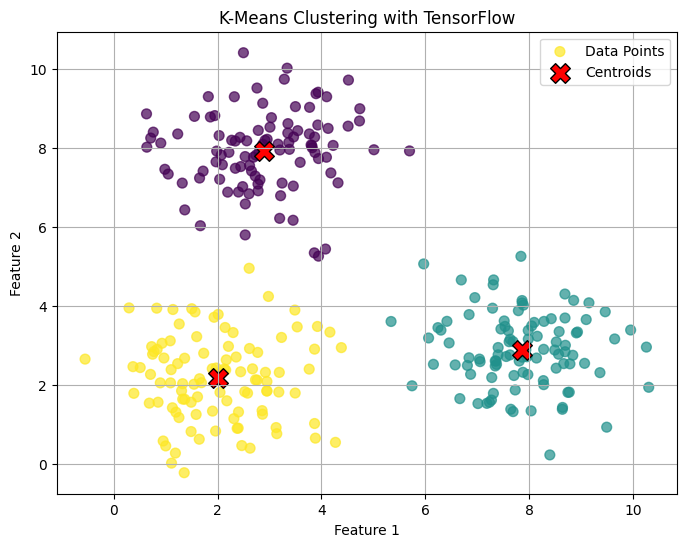

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate some dummy data
num_samples = 300
num_features = 2
num_clusters = 3

# Create three distinct clusters
np.random.seed(0)
cluster_centers = np.array([[2, 2], [8, 3], [3, 8]], dtype=np.float32)
X = np.concatenate([
    np.random.randn(100, num_features) + cluster_centers[0],
    np.random.randn(100, num_features) + cluster_centers[1],
    np.random.randn(100, num_features) + cluster_centers[2]
], axis=0)
X = tf.constant(X, dtype=tf.float32)

# 2. Randomly initialize centroids
# Pick k random data points as initial centroids
random_indices = tf.random.shuffle(tf.range(num_samples))[:num_clusters]
centroids = tf.Variable(tf.gather(X, random_indices))

# K-Means Algorithm Parameters
max_iterations = 100

# 3. Iterative K-Means algorithm
print("Starting K-Means Clustering...")
for i in range(max_iterations):
    # a. Calculate distances from points to centroids (Euclidean distance)
    # Expand dims for broadcasting
    expanded_X = tf.expand_dims(X, axis=1) # Shape: (num_samples, 1, num_features)
    expanded_centroids = tf.expand_dims(centroids, axis=0) # Shape: (1, num_clusters, num_features)

    distances = tf.reduce_sum(tf.square(expanded_X - expanded_centroids), axis=2) # Shape: (num_samples, num_clusters)

    # b. Assign each point to the nearest centroid
    cluster_assignments = tf.argmin(distances, axis=1) # Shape: (num_samples,)

    # c. Update centroids based on assigned points
    new_centroids = []
    for k in range(num_clusters):
        # Select all points assigned to cluster k
        points_in_cluster = tf.gather_nd(X, tf.where(tf.equal(cluster_assignments, k)))
        if tf.shape(points_in_cluster)[0] > 0: # Ensure there are points in the cluster
            new_centroids.append(tf.reduce_mean(points_in_cluster, axis=0))
        else:
            # If a cluster becomes empty, re-initialize its centroid to a random point
            new_centroids.append(tf.gather(X, tf.random.uniform(shape=[1], minval=0, maxval=num_samples, dtype=tf.int32))[0])

    new_centroids = tf.stack(new_centroids)

    # Check for convergence
    if tf.reduce_all(tf.equal(centroids, new_centroids)):
        print(f"Converged after {i+1} iterations.")
        break
    centroids.assign(new_centroids)
else:
    print(f"Finished {max_iterations} iterations without convergence.")

# 4. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=cluster_assignments.numpy(), cmap='viridis', s=50, alpha=0.7, label='Data Points')
plt.scatter(centroids[:, 0].numpy(), centroids[:, 1].numpy(), marker='X', s=200, c='red', edgecolor='black', label='Centroids')
plt.title('K-Means Clustering with TensorFlow')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import tensorflow_probability as tfp
import tensorflow as tf
import numpy as np

tfd = tfp.distributions

# Define the HMM parameters conceptually
# For a simple HMM with 2 hidden states and 3 possible observations

# 1. Initial State Distribution (pi)
# Probability of starting in state 0 or state 1
initial_distribution = tfd.Categorical(probs=[0.8, 0.2]) # e.g., 80% start in state 0, 20% in state 1

# 2. Transition Distribution (A)
# Probability of transitioning from state i to state j
# Row i: current state, Column j: next state
# e.g., if in state 0: 70% stay in 0, 30% go to 1
#       if in state 1: 40% go to 0, 60% stay in 1
transition_distribution = tfd.Categorical(probs=[[0.7, 0.3],
                                                  [0.4, 0.6]])

# 3. Observation Distribution (B)
# Probability of observing an event given the current hidden state
# Each hidden state has its own emission probabilities for the observations
# Here, observations are discrete (e.g., 0, 1, 2)
# e.g., if in state 0: 50% observe 0, 40% observe 1, 10% observe 2
#       if in state 1: 10% observe 0, 20% observe 1, 70% observe 2
observation_distribution = tfd.Categorical(probs=[[0.5, 0.4, 0.1],
                                                  [0.1, 0.2, 0.7]])

# Create the Hidden Markov Model
hmm = tfd.HiddenMarkovModel(
    initial_distribution=initial_distribution,
    transition_distribution=transition_distribution,
    observation_distribution=observation_distribution,
    num_steps=10  # Length of the sequence
)

# --- Example Usage ---

# 1. Sample a sequence of observations from the HMM
print("\n--- Sampling Observations ---")
sampled_observations = hmm.sample()
print(f"Sampled observations (sequence of length {hmm.num_steps}): {sampled_observations.numpy()}")

# 2. Calculate the log probability of an observed sequence
# Let's say we have an observed sequence, e.g., [0, 1, 0, 2, 1, 0, 2, 2, 1, 0]
observed_sequence = tf.constant([0, 1, 0, 2, 1, 0, 2, 2, 1, 0], dtype=tf.int32)
log_prob_sequence = hmm.log_prob(observed_sequence)
print(f"Log probability of observed sequence {observed_sequence.numpy()}: {log_prob_sequence.numpy():.4f}")

# 3. Infer the most likely sequence of hidden states (Viterbi algorithm)
# This is a common task: given observations, what were the most likely underlying states?
# TFP's HMM distribution can compute this.
# (Note: For this, we need to manually implement Viterbi or use external libraries,
# as the direct `hmm.posterior_mode()` is not available for `HiddenMarkovModel` directly to get state sequence,
# but `log_marginal_likelihood` can be computed. Let's show a conceptual approach)

# For Viterbi, typically you'd use a dedicated library or implement it.
# TFP's HMM itself is mainly for probability calculations.
# For illustrative purposes, let's just indicate the concept of finding states.
print("\n--- Inferring Hidden States (Conceptual) ---")
print("Given an observed sequence, one can use algorithms like Viterbi to infer the most likely sequence of hidden states.")
# For example, if we were using a library like `hmmlearn` in Python, it would look something like:
# from hmmlearn import hmm
# model = hmm.CategoricalHMM(n_components=2)
# model.startprob_ = [0.8, 0.2]
# model.transmat_ = [[0.7, 0.3], [0.4, 0.6]]
# model.emissionprob_ = [[0.5, 0.4, 0.1], [0.1, 0.2, 0.7]]
# logprob, state_sequence = model.decode(observed_sequence.numpy().reshape(-1, 1), algorithm="viterbi")
# print(f"Most likely hidden state sequence: {state_sequence}")

print("\nThis example uses `tfp.distributions.HiddenMarkovModel` to define and sample from an HMM, and calculate the probability of a given sequence. For actual inference of hidden states (like Viterbi), you might integrate with other libraries or implement the algorithm using TensorFlow operations.")


--- Sampling Observations ---
Sampled observations (sequence of length 10): [0 1 1 1 0 2 1 2 1 2]
Log probability of observed sequence [0 1 0 2 1 0 2 2 1 0]: -10.9238

--- Inferring Hidden States (Conceptual) ---
Given an observed sequence, one can use algorithms like Viterbi to infer the most likely sequence of hidden states.

This example uses `tfp.distributions.HiddenMarkovModel` to define and sample from an HMM, and calculate the probability of a given sequence. For actual inference of hidden states (like Viterbi), you might integrate with other libraries or implement the algorithm using TensorFlow operations.


## Advanced TensorFlow Learning Paths

Having covered fundamental concepts like Keras Functional API for structured data, preprocessing layers, and specific algorithms like K-Means-like clustering and Hidden Markov Models, here are some advanced learning paths to deepen your TensorFlow expertise:

1.  **Distributed Training with TensorFlow**: Explore `tf.distribute.Strategy` for scaling model training across multiple GPUs, multiple machines, or TPUs. This is crucial for large-scale models and datasets.
2.  **TensorFlow Extended (TFX)**: Learn about an end-to-end platform for deploying production ML pipelines. TFX components include data validation, feature engineering, model training, evaluation, and serving, ensuring robust and scalable ML systems.
3.  **TensorFlow Lite and TensorFlow.js**: Dive into deploying TensorFlow models on edge devices (mobile, IoT) with TensorFlow Lite or directly in web browsers with TensorFlow.js. This involves understanding model quantization, optimization, and specific API usage.
4.  **Custom Training Loops and Advanced Optimization**: Beyond `model.fit()`, explore writing custom training loops for fine-grained control over the training process, gradient computation, and integrating with advanced optimizers or custom loss functions.
5.  **Generative Adversarial Networks (GANs) and Variational Autoencoders (VAEs)**: Delve into generative models for tasks like image generation, style transfer, and anomaly detection. This involves complex architectures and training strategies.
6.  **Reinforcement Learning with TensorFlow (TF-Agents)**: Explore building and training reinforcement learning agents for tasks involving sequential decision-making in dynamic environments.
7.  **TensorFlow Privacy**: Learn how to build privacy-preserving machine learning models using differential privacy techniques, which is critical for sensitive data.
8.  **Graph Neural Networks (GNNs)**: Investigate models designed to operate on graph-structured data, enabling applications in social network analysis, drug discovery, and recommender systems.

## Summary of Explanations

Throughout this session, we've explored several key aspects of TensorFlow:

*   **Core Concepts**: An introduction to TensorFlow's graph and session paradigm (though primarily focusing on TF2.x's eager execution), tensors, and various tensor types.
*   **Keras Model for Structured Data**: We detailed the construction of a Keras Functional API model, emphasizing input pipeline creation (`make_input_function`), the role of Keras preprocessing layers (`Normalization`, `StringLookup`, `CategoryEncoding`) for feature engineering, and the standard training/evaluation flow (`model.compile`, `model.fit`, `model.evaluate`).
*   **Clustering (K-Means-like)**: We discussed the concept of unsupervised clustering, its applications, and demonstrated a conceptual K-Means algorithm implementation using core TensorFlow operations.
*   **Hidden Markov Models**: We explained the components and applications of HMMs for sequential data, providing a conceptual example using the `tfp.distributions.HiddenMarkovModel` from TensorFlow Probability.

These topics provide a solid foundation for building and understanding machine learning models in TensorFlow, covering both traditional ML algorithms adapted for TensorFlow and modern deep learning paradigms.

---

I hope these detailed explanations and conceptual examples have been helpful. If you'd like, I can:

*   Generate more detailed code examples for any of the suggested advanced topics.
*   Dive deeper into the theoretical underpinnings of any specific model or concept.
*   Help with specific TensorFlow-related coding challenges.

Please let me know how you'd like to proceed!

## Advanced TensorFlow Learning Paths

Having covered fundamental concepts like Keras Functional API for structured data, preprocessing layers, and specific algorithms like K-Means-like clustering and Hidden Markov Models, here are some advanced learning paths to deepen your TensorFlow expertise:

1.  **Distributed Training with TensorFlow**: Explore `tf.distribute.Strategy` for scaling model training across multiple GPUs, multiple machines, or TPUs. This is crucial for large-scale models and datasets.
2.  **TensorFlow Extended (TFX)**: Learn about an end-to-end platform for deploying production ML pipelines. TFX components include data validation, feature engineering, model training, evaluation, and serving, ensuring robust and scalable ML systems.
3.  **TensorFlow Lite and TensorFlow.js**: Dive into deploying TensorFlow models on edge devices (mobile, IoT) with TensorFlow Lite or directly in web browsers with TensorFlow.js. This involves understanding model quantization, optimization, and specific API usage.
4.  **Custom Training Loops and Advanced Optimization**: Beyond `model.fit()`, explore writing custom training loops for fine-grained control over the training process, gradient computation, and integrating with advanced optimizers or custom loss functions.
5.  **Generative Adversarial Networks (GANs) and Variational Autoencoders (VAEs)**: Delve into generative models for tasks like image generation, style transfer, and anomaly detection. This involves complex architectures and training strategies.
6.  **Reinforcement Learning with TensorFlow (TF-Agents)**: Explore building and training reinforcement learning agents for tasks involving sequential decision-making in dynamic environments.
7.  **TensorFlow Privacy**: Learn how to build privacy-preserving machine learning models using differential privacy techniques, which is critical for sensitive data.
8.  **Graph Neural Networks (GNNs)**: Investigate models designed to operate on graph-structured data, enabling applications in social network analysis, drug discovery, and recommender systems.

## Summary of Explanations

Throughout this session, we've explored several key aspects of TensorFlow:

*   **Core Concepts**: An introduction to TensorFlow's graph and session paradigm (though primarily focusing on TF2.x's eager execution), tensors, and various tensor types.
*   **Keras Model for Structured Data**: We detailed the construction of a Keras Functional API model, emphasizing input pipeline creation (`make_input_function`), the role of Keras preprocessing layers (`Normalization`, `StringLookup`, `CategoryEncoding`) for feature engineering, and the standard training/evaluation flow (`model.compile`, `model.fit`, `model.evaluate`).
*   **Clustering (K-Means-like)**: We discussed the concept of unsupervised clustering, its applications, and demonstrated a conceptual K-Means algorithm implementation using core TensorFlow operations.
*   **Hidden Markov Models**: We explained the components and applications of HMMs for sequential data, providing a conceptual example using the `tfp.distributions.HiddenMarkovModel` from TensorFlow Probability.

These topics provide a solid foundation for building and understanding machine learning models in TensorFlow, covering both traditional ML algorithms adapted for TensorFlow and modern deep learning paradigms.

---

I hope these detailed explanations and conceptual examples have been helpful. If you'd like, I can:

*   Generate more detailed code examples for any of the suggested advanced topics.
*   Dive deeper into the theoretical underpinnings of any specific model or concept.
*   Help with specific TensorFlow-related coding challenges.

Please let me know how you'd like to proceed!


## Suggest Advanced TensorFlow Learning Paths

### Subtask:
Provide a high-level overview and suggestions for advanced TensorFlow topics in a new text cell.


## Advanced TensorFlow Learning Paths

Having covered the fundamentals of TensorFlow, including tensor manipulation, Keras model construction, and basic training/evaluation, there's a vast landscape of advanced topics to explore for building more powerful, efficient, and production-ready machine learning systems.

Here are some suggested advanced learning paths:

1.  **Custom Layers and Models**: While Keras provides a rich set of predefined layers, often you'll encounter scenarios where custom logic is needed. Learning to subclass `tf.keras.layers.Layer` and `tf.keras.Model` allows for complete control over computations, state management, and reusable components. This is crucial for implementing novel architectures or integrating specialized operations.

2.  **Custom Training Loops and Gradient Tape**: Beyond `model.fit()`, understanding `tf.GradientTape` is fundamental for implementing custom training loops. This provides maximum flexibility to control every step of the training process, such as applying custom loss functions, implementing complex optimization schedules, or using advanced gradient manipulation techniques (e.g., gradient clipping, adversarial training). It's also essential for research and non-standard model architectures.

3.  **Performance Optimization with `tf.data` and Profiling**: Efficient data input pipelines are critical for training large models on vast datasets. Deep dive into `tf.data` API for advanced techniques like prefetching, caching, interleaved dataset reading, and parallel transformations. Additionally, learning to use TensorFlow's profiler tools (`tf.summary.trace_on`, TensorBoard profiler) is key to identifying and resolving performance bottlenecks in your models and data pipelines.

4.  **Distributed Training**: For training models on very large datasets or with complex architectures, distributed training becomes necessary. Explore TensorFlow's strategies for distributing training across multiple GPUs on a single machine (`MirroredStrategy`) or across multiple machines (`MultiWorkerMirroredStrategy`, `TPUStrategy`), enabling faster experimentation and scaling.

5.  **TensorFlow Extended (TFX)**: TFX is an end-to-end platform for deploying production ML pipelines. It goes beyond model training to cover data validation (`TFDV`), feature engineering (`TFTransform`), model analysis (`TFMA`), and model serving (`TFServing`). Learning TFX is essential for transitioning ML projects from experimentation to reliable production systems.

6.  **TensorFlow Lite and TensorFlow.js**: For deploying models to edge devices (mobile, IoT) or web browsers, TensorFlow offers specialized runtimes. TensorFlow Lite focuses on on-device inference with optimized, small models. TensorFlow.js enables direct execution of ML models in the browser or Node.js, opening up opportunities for interactive ML applications.

7.  **TensorFlow Probability (TFP)**: For statistical modeling, probabilistic machine learning, and Bayesian inference, TFP extends TensorFlow with tools to build and train models using probability distributions. This is valuable for tasks requiring uncertainty quantification, such as robust anomaly detection or risk assessment.

8.  **Reinforcement Learning with TF-Agents**: If you're interested in building agents that learn through interaction with an environment, TF-Agents provides a rich library of modular components to design, implement, and train reinforcement learning agents within TensorFlow.

These advanced topics build upon the core TensorFlow knowledge and open doors to tackling more complex real-world machine learning challenges.

## Summary:

### Data Analysis Key Findings
*   **Clustering Explanation and Example**: A comprehensive explanation of Clustering, including its applications in TensorFlow (e.g., Customer Segmentation, Image Segmentation, Anomaly Detection), was provided. A conceptual K-Means clustering algorithm was implemented using TensorFlow operations, which successfully converged in 11 iterations for 300 2D data points forming 3 clusters and visualized the results.
*   **Hidden Markov Models (HMMs) Explanation and Example**: HMMs were explained with their key components (Hidden States, Observations, Transition Probabilities, Emission Probabilities, Initial State Probabilities) and typical TensorFlow applications (e.g., Speech Recognition, NLP, Bioinformatics). A conceptual code example using `tfp.distributions.HiddenMarkovModel` from TensorFlow Probability demonstrated sampling observations and calculating the log probability of a given sequence.
*   **Advanced TensorFlow Learning Paths**: Eight advanced learning paths were suggested, covering topics such as Distributed Training, TensorFlow Extended (TFX), TensorFlow Lite and TensorFlow.js, Custom Training Loops, GANs/VAEs, Reinforcement Learning (TF-Agents), TensorFlow Privacy, and Graph Neural Networks (GNNs).
*   **Overall Summary**: The analysis summarized the key topics covered, which included TensorFlow Core Concepts, Keras Functional API, Clustering (K-Means-like), and Hidden Markov Models.

### Insights or Next Steps
*   The provided explanations and conceptual code examples serve as a solid foundation for understanding and applying these machine learning algorithms within TensorFlow.
*   The comprehensive list of advanced TensorFlow learning paths offers clear directions for further skill development and deeper exploration into specialized areas of machine learning.


### Neural Networks


In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
#Dataset
fashion_mnist=keras.datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
train_images[0,24,24]

np.uint8(99)

In [ ]:
#Data Preprocessing
#Normalization
train_images=train_images/255.
test_images=test_images/255.

In [ ]:
#Build the model
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(train_images,train_labels,epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7806 - loss: 0.6381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8641 - loss: 0.3809
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8753 - loss: 0.3398
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8860 - loss: 0.3128
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8924 - loss: 0.2918
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8947 - loss: 0.2807
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9006 - loss: 0.2657
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9045 - loss: 0.2528
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9073 - loss: 0.2478
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9122 - loss: 0.2336


## Explanation of `verbose`

The term **verbose** refers to how much information a function or method will print to the console during its execution. It controls the level of output detail.

In the context of machine learning, especially with libraries like TensorFlow and Keras, you'll often see a `verbose` argument in functions like `model.fit()`, `model.evaluate()`, or even in some utility functions.

Here are the common meanings for `verbose` in Keras `model.fit()` and `model.evaluate()`:

*   **`verbose=0` (silent)**: Nothing will be printed to the console. The process will run without showing any progress or intermediate results.
*   **`verbose=1` (progress bar)**: This is often the default. It will display a progress bar for each epoch (in `model.fit()`) or for the entire evaluation process (in `model.evaluate()`). For `model.fit()`, it typically shows the current epoch number, the time taken, and the metrics you're tracking (loss, accuracy, etc.).
*   **`verbose=2` (one line per epoch)**: For `model.fit()`, it will print one line of information per epoch, summarizing the results (loss, accuracy, etc.) for that epoch. For `model.evaluate()`, it's usually equivalent to `verbose=1` or prints a single summary line without a progress bar.

Choosing the `verbose` level depends on your needs:
*   Use `verbose=1` during interactive development to monitor training progress.
*   Use `verbose=0` when running production code or long-running experiments where you don't need constant console output, or when you are logging metrics elsewhere (e.g., to TensorBoard or a file).

In [ ]:
#Evaluate
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=1)
test_loss,test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8841 - loss: 0.3431


(0.34263306856155396, 0.8833000063896179)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


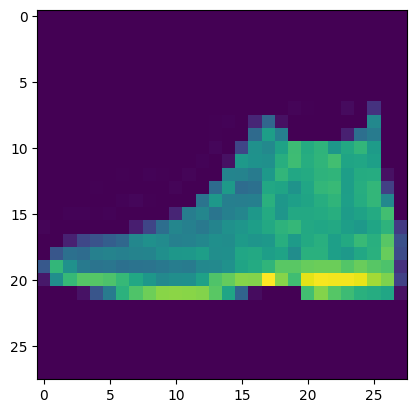

In [ ]:
#Predictions
# Reshape the single image to include a batch dimension (1, 28, 28)
predictions = model.predict(test_images[0][np.newaxis, ...])
predictions.argmax()
plt.figure()
plt.imshow(test_images[0])
plt.show()

In [ ]:
test_labels[0]

np.uint8(9)

### Deep Computer Vision-CNN
* Image Data
* Convolutional layer
* Pooling layer
* CNN architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

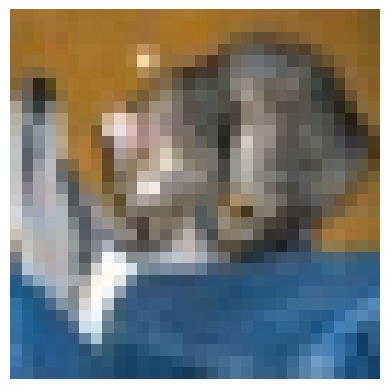

In [ ]:
train_images=train_images/255.
test_images=test_images/255.
plt.imshow(test_images[0],cmap=plt.cm.binary)
plt.axis("off")


In [ ]:
model=keras.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64,(2,2),activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64,(2,2),activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,600 (100.00 KB)

 Trainable params: 25,600 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Add Dense Layers
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,770 (678.79 KB)

 Trainable params: 173,770 (678.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
model.fit(train_images,train_labels,epochs=10,validation_data=(test_images,test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.3619 - loss: 1.7263 - val_accuracy: 0.5393 - val_loss: 1.2819
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.5901 - loss: 1.1610 - val_accuracy: 0.6235 - val_loss: 1.0861
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.6542 - loss: 0.9863 - val_accuracy: 0.6747 - val_loss: 0.9382
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 65ms/step - accuracy: 0.6916 - loss: 0.8819 - val_accuracy: 0.6944 - val_loss: 0.8967
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7170 - loss: 0.8065 - val_accuracy: 0.6999 - val_loss: 0.8666
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 56ms/step - accuracy: 0.7437 - loss: 0.7399 - val_accuracy: 0.7054 - val_loss: 0.8571
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 156s 65ms/step - accuracy: 0.7566 - loss: 0.6909 - val_accuracy: 0.7170 - val_loss: 0.8211
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7750

## Explanation of `Conv2D` and `MaxPool2D` Layers in Your Model

Let's break down the `Conv2D` and `MaxPool2D` layers, which are the fundamental building blocks of the Convolutional Neural Network (CNN) you've defined:

### `layers.Conv2D` (Convolutional Layer)

This is the core layer responsible for feature extraction in CNNs. It works by sliding a small filter (also called a kernel) over the input data to detect patterns.

*   **`32`**: This is the number of filters (or output feature maps) this layer will learn. In your first `Conv2D` layer, it will learn 32 distinct patterns/features. The output of this layer will have 32 channels.
*   **`(3,3)`**: This specifies the dimensions of the convolution window (the filter). In this case, it's a 3x3 pixel filter. This filter moves across the image, performing element-wise multiplications with the input pixels it covers and then summing the results to produce a single value in the output feature map.
*   **`activation='relu'`**: After the convolution operation, a non-linear activation function is applied. 'ReLU' (Rectified Linear Unit) is very commonly used in hidden layers. It outputs the input value directly if it's positive (`x`), otherwise it outputs zero (`max(0, x)`). This non-linearity is crucial for the network to learn complex relationships.
*   **`input_shape=(32,32,3)`**: This argument is specifically required for the *first* layer in a `Sequential` model to inform the model about the expected dimensions of its input. Here, `(32,32,3)` signifies that the input images are 32 pixels in height, 32 pixels in width, and have 3 color channels (typically Red, Green, Blue).
*   **`(2,2)`**: In your subsequent `Conv2D` layer, this denotes a 2x2 filter size.

### `layers.MaxPool2D` (Max Pooling Layer)

This layer is used to progressively reduce the spatial dimensions (width and height) of the feature maps, a process known as downsampling.

*   **`(2,2)`**: This specifies the size of the pooling window (or filter). A 2x2 pooling window means the layer will slide a 2x2 block across the input feature map and select the maximum value within each block. This effectively halves the height and width of the feature maps. For example, if a `Conv2D` layer outputs a 28x28 feature map, a `MaxPool2D((2,2))` layer would reduce it to 14x14.
*   **Purpose of Max Pooling**:
    *   **Dimensionality Reduction**: Reduces the number of parameters and computational cost, which helps to speed up training and make the model less prone to overfitting.
    *   **Translational Invariance**: Makes the detected features more robust to minor shifts or distortions in the input image. If a feature is present anywhere within the pooling window, its maximum value will be carried forward, making the exact location less critical.

### How they work together in your CNN:

Your model uses a common pattern of stacking convolutional and pooling layers:

1.  **First `Conv2D`**: Extracts initial features (e.g., edges, corners) from the 32x32x3 input image using 32 different 3x3 filters, followed by ReLU activation.
2.  **First `MaxPool2D`**: Downsamples the feature maps produced by the first convolutional layer, reducing their size (e.g., if the Conv2D output was 30x30x32, this would become 15x15x32).
3.  **Second `Conv2D`**: Extracts more complex, higher-level features from the downsampled feature maps using 64 different 2x2 filters, followed by ReLU activation.
4.  **Second `MaxPool2D`**: Further downsamples these new feature maps.
5.  **Third `Conv2D`**: Continues to extract even more abstract features, again using 64 different 2x2 filters and ReLU activation.

This architecture allows the CNN to learn a hierarchy of features, starting from simple patterns and combining them into more complex representations, which are then used for classification.

## Explanation of `Dense` Layers in Your Model

After the convolutional and pooling layers, your model adds `Dense` layers. These are crucial for the final classification step.

### `tf.keras.layers.Dense` (Fully Connected Layer)

*   **Purpose**: A `Dense` layer, also known as a fully connected layer, is where the network learns global patterns and makes final predictions based on the features extracted by the preceding convolutional and pooling layers. Each neuron in a `Dense` layer is connected to every neuron in the previous layer.

*   **How it works**: For each neuron in a `Dense` layer, it computes a weighted sum of all inputs from the previous layer, adds a bias term, and then passes this result through an activation function. This process allows the network to combine and interpret the extracted features in complex ways.

*   **Location in your CNN**: In your model, `Dense` layers are added after a `Flatten` layer (though `Flatten` is not explicitly shown in the snippet you asked about, it's implied before the first Dense layer to convert the 3D output of the Conv/MaxPool stack into a 1D vector). The `Dense` layers perform the final classification.

*   **Arguments in your model**:
    *   **`64` (first Dense layer)**: This specifies the number of neurons (output units) in this hidden dense layer. It means this layer will produce an output vector of 64 values. The `activation='relu'` adds non-linearity, which helps the network learn complex relationships.
    *   **`10` (second Dense layer)**: This is the final output layer. The `10` units correspond to the 10 possible classes (e.g., in the CIFAR-10 dataset, which has 10 categories like 'airplane', 'automobile', 'bird', etc.). Since you didn't specify an activation here (`model.add(layers.Dense(10))`), it implicitly uses a linear activation. However, for multi-class classification, a `softmax` activation is typically applied in the `model.compile` step (via `from_logits=True` in the loss function) or directly in the layer, to output class probabilities.

### In your CNN architecture, the `Dense` layers play the role of the "classifier head":

1.  The `Conv2D` and `MaxPool2D` layers **extract a rich set of features** from the input image, gradually reducing its spatial dimensions while increasing the depth (number of feature maps).
2.  A `Flatten` layer (implicitly or explicitly present before the first `Dense` layer) converts this 3D feature map into a **1D vector**.
3.  The **`Dense(64, activation='relu')`** layer then takes this 1D feature vector and learns a set of 64 abstract representations (neurons) from it, introducing non-linearity.
4.  Finally, the **`Dense(10)`** layer takes the output from the 64-neuron layer and maps it to the 10 output classes. The loss function, `tf.losses.SparseCategoricalCrossentropy(from_logits=True)`, handles the conversion of these raw outputs (logits) into probabilities and calculates the loss.

## Explanation of `SparseCategoricalCrossentropy`

`SparseCategoricalCrossentropy` is a loss function used in TensorFlow and Keras for multi-class classification problems. It measures the dissimilarity between the true labels and the predicted probabilities produced by a classification model.

### When to use it:

YouYou should use `SparseCategoricalCrossentropy` when your true labels are **integers** (e.g., 0, 1, 2, ..., `num_classes - 1`). Each integer corresponds to a specific class. This is common when your labels are directly stored as numerical class IDs.

### How it works:

1.  **Input**: It expects two main inputs:
    *   **True labels (y_true)**: These should be integers representing the class index (e.g., `[1, 0, 2]` for three samples belonging to class 1, class 0, and class 2 respectively).
    *   **Predicted probabilities (y_pred)**: These are typically the raw outputs (logits) from the final dense layer of your model *before* applying a softmax activation, or the probabilities after applying softmax, depending on the `from_logits` argument (explained below).

2.  **Internal One-Hot Encoding**: If `from_logits=False` and your model's output layer uses a `softmax` activation (which it should for classification), `SparseCategoricalCrossentropy` internally converts your integer `y_true` labels into a one-hot encoded format. For example, if you have 3 classes and `y_true` is `1`, it would be converted to `[0, 1, 0]`.

3.  **Cross-Entropy Calculation**: It then calculates the cross-entropy loss between the one-hot encoded true labels and the predicted probability distribution. Cross-entropy quantifies how different two probability distributions are.

### Key Argument: `from_logits`

*   **`from_logits=True`**: This is a very common and often recommended setting. It means your model's final layer should output raw, unnormalized scores (logits) for each class, without an activation function (or with a linear activation). The `SparseCategoricalCrossentropy` loss function will then internally apply a softmax activation to these logits and compute the cross-entropy loss. This approach offers numerical stability benefits.

*   **`from_logits=False`**: This means your model's final layer *must* output probabilities (usually by applying a `softmax` activation). The `SparseCategoricalCrossentropy` function will then directly compute the cross-entropy loss using these probabilities.

### `SparseCategoricalCrossentropy` vs. `CategoricalCrossentropy`

The main difference between these two loss functions lies in the format of the `y_true` (true labels):

*   **`SparseCategoricalCrossentropy`**: Used when `y_true` are **integers** (class indices).
    *   Example `y_true`: `[1, 0, 2]`

*   **`CategoricalCrossentropy`**: Used when `y_true` are **one-hot encoded vectors**.
    *   Example `y_true`: `[[0, 1, 0], [1, 0, 0], [0, 0, 1]]`

If you have integer labels and accidentally use `CategoricalCrossentropy`, you would need to manually one-hot encode your labels first (e.g., using `tf.keras.utils.to_categorical`). `SparseCategoricalCrossentropy` simplifies this by handling the one-hot encoding internally.

In [ ]:
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2)
test_loss,test_acc

313/313 - 4s - 13ms/step - accuracy: 0.7170 - loss: 0.8671


### Data Augmentation

/tmp/ipython-input-2936100785.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7ac2414c1580> (for post_execute):


KeyboardInterrupt: 

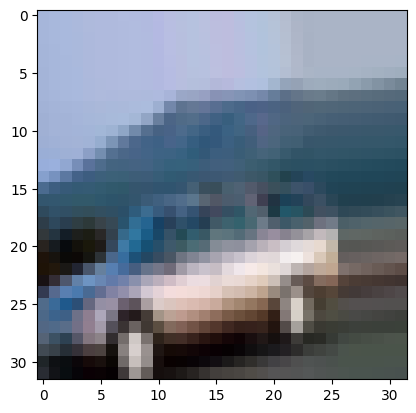

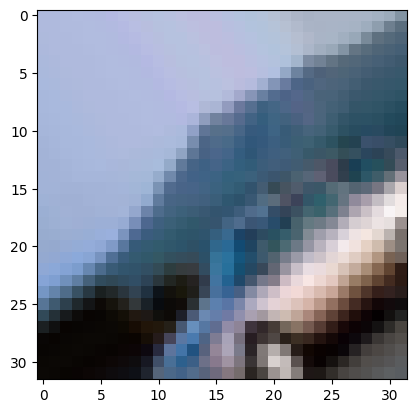

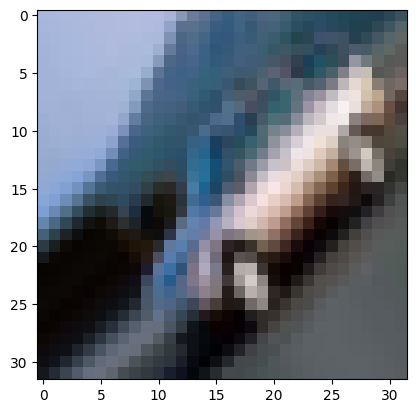

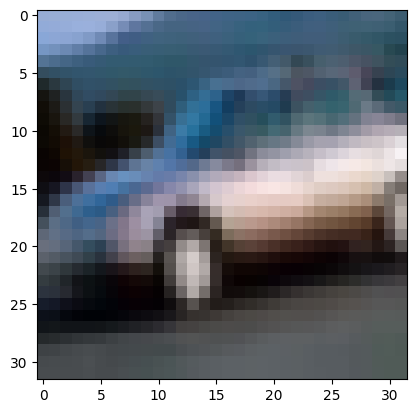

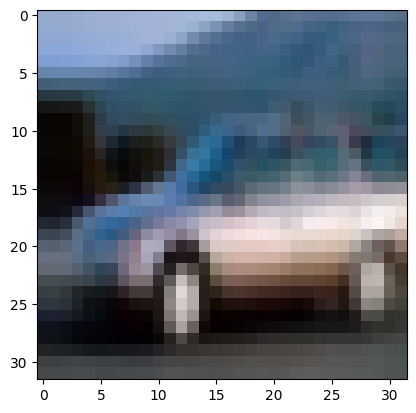

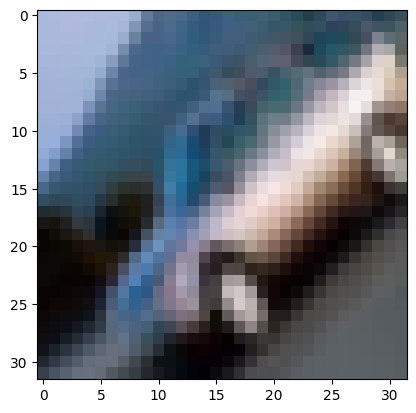

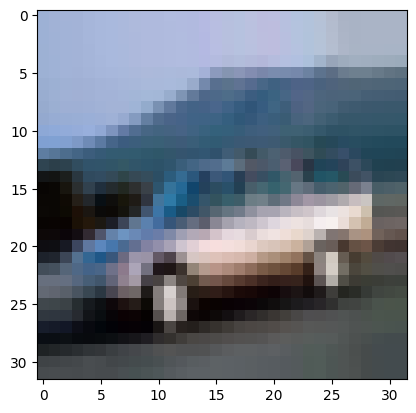

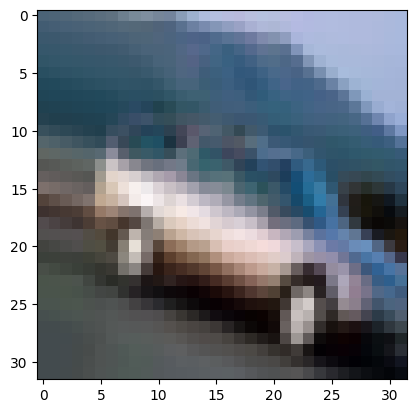

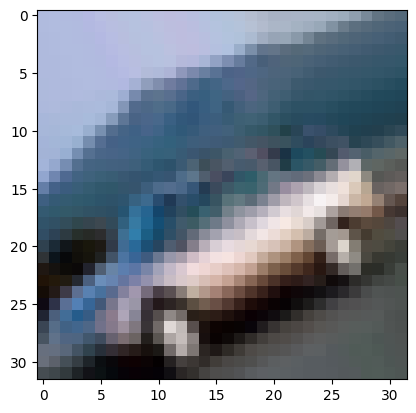

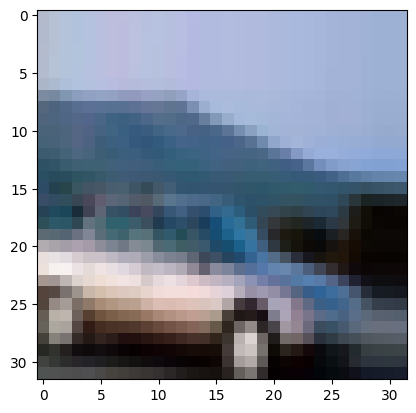

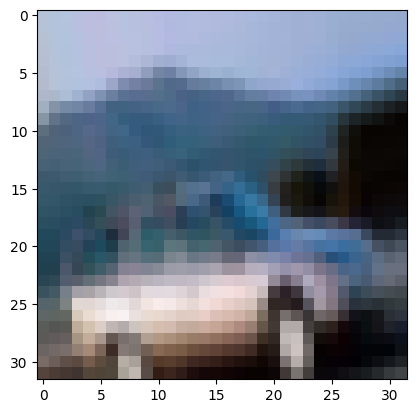

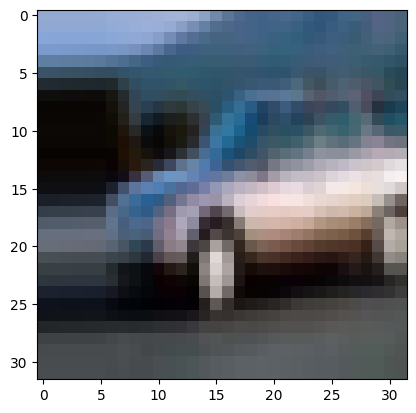

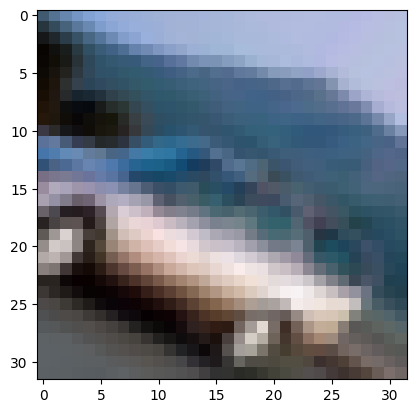

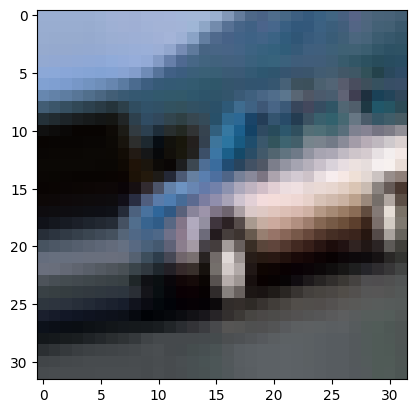

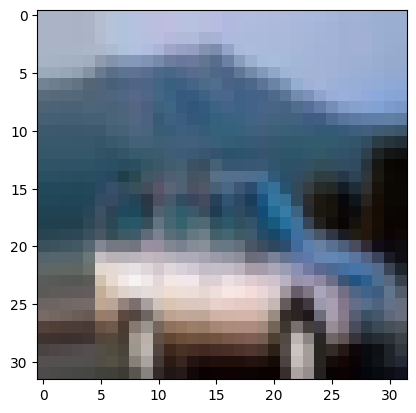

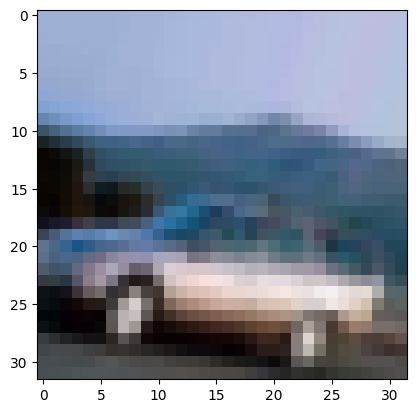

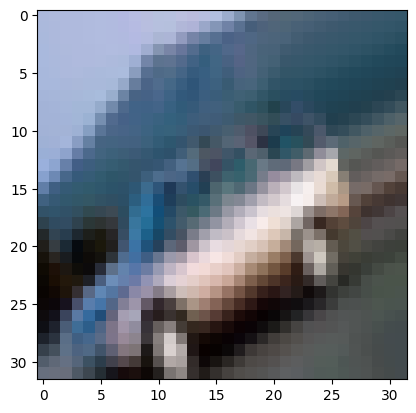

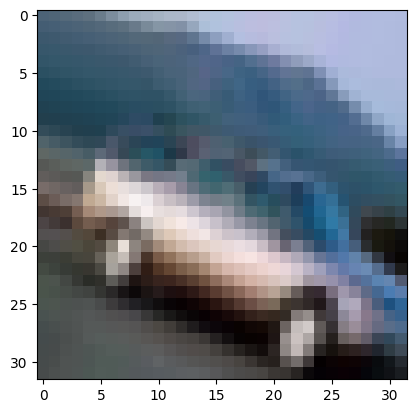

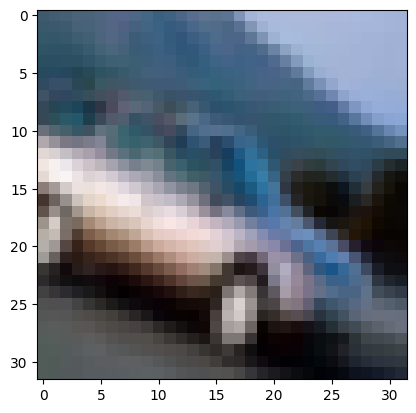

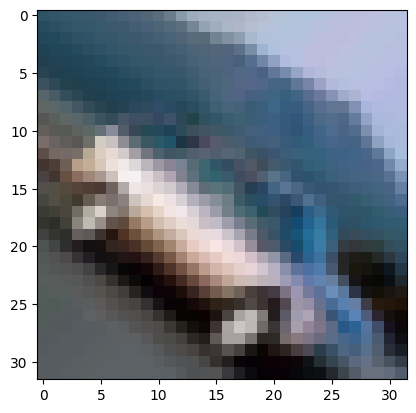

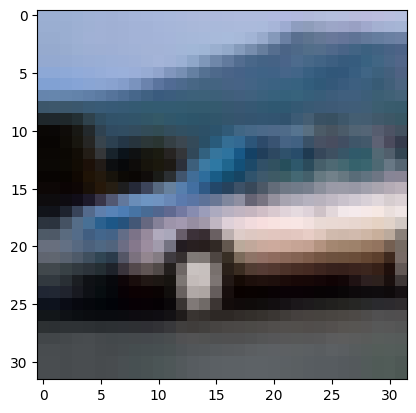

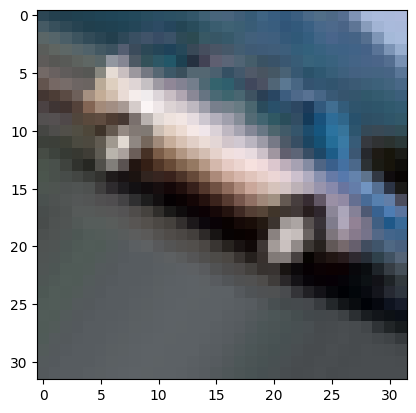

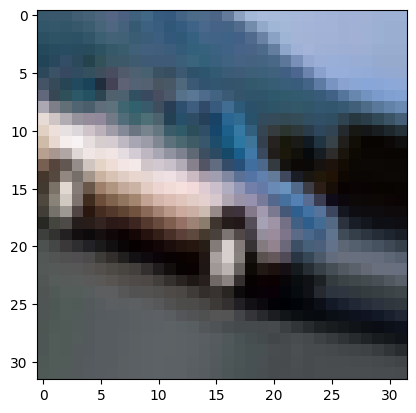

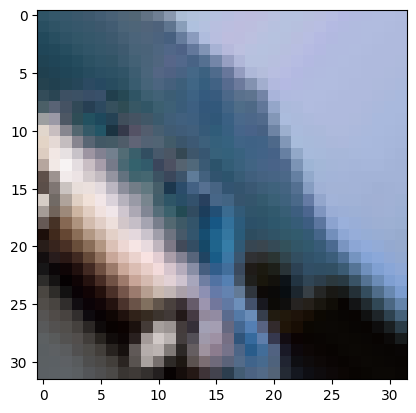

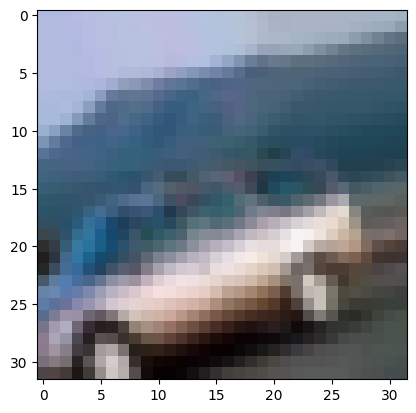

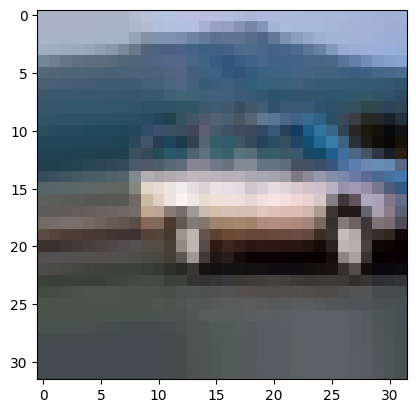

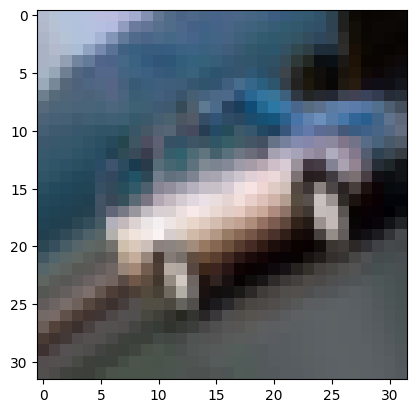

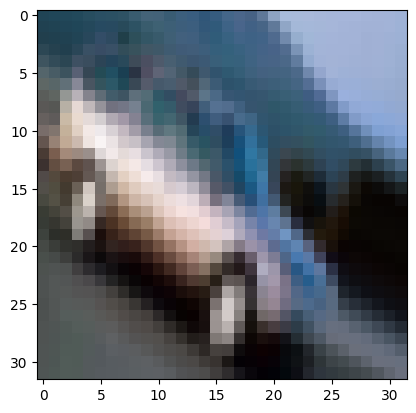

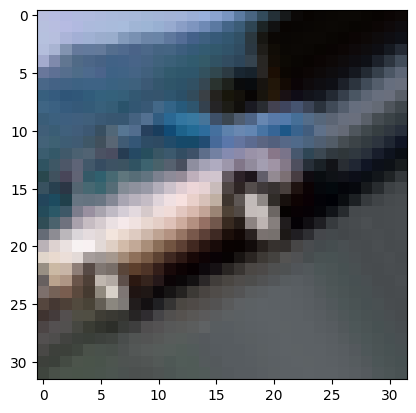

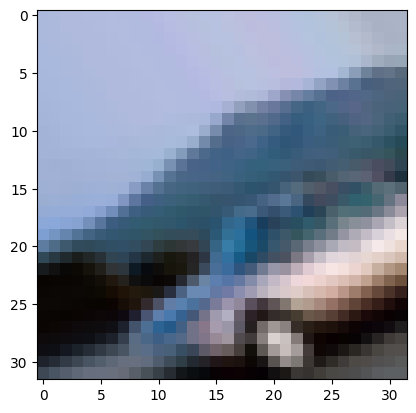

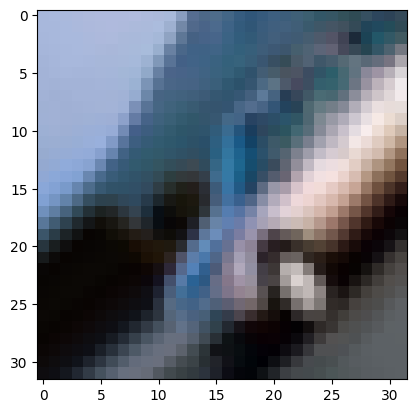

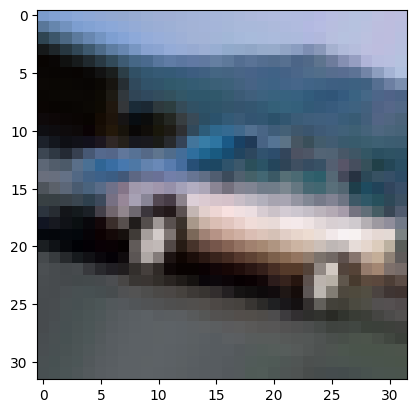

Error in callback <function flush_figures at 0x7ac2414c0fe0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_gen=ImageDataGenerator(
    rotation_range=40,

    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
img=train_images[4]
img=image.img_to_array(img)
img=img.reshape((1,)+img.shape)
i=0
for batch in data_gen.flow(img,save_prefix='test',save_format='jpeg'):
  plt.figure()
  plt.imshow(image.img_to_array(batch[0]))
  i+=1
  if i<4:
    break

## Explanation of `ImageDataGenerator` for Data Augmentation

`ImageDataGenerator` is a utility class provided by Keras (part of `tf.keras.preprocessing.image`) that allows for on-the-fly data augmentation and efficient loading of image data for training deep learning models.

### What is Data Augmentation?

Data augmentation is a technique used to increase the diversity of training data by applying random but realistic transformations to the original images. These transformations can include:

*   **Rotations**: Rotating the image by a certain degree.
*   **Shifts**: Shifting the image horizontally or vertically.
*   **Flips**: Flipping the image horizontally or vertically.
*   **Zooms**: Zooming in or out of the image.
*   **Brightness changes**: Adjusting the brightness of the image.
*   **Shear transformations**: Tilting the image.

### Why is Data Augmentation Important?

1.  **Prevent Overfitting**: By providing a wider variety of training examples, data augmentation helps the model generalize better to unseen data and reduces overfitting, especially when the original dataset is small.
2.  **Improve Model Robustness**: It makes the model more robust to variations in the input data (e.g., different lighting conditions, slight rotations, or shifts in object position).
3.  **Increase Dataset Size (Virtually)**: It effectively expands the size of your training dataset without actually collecting more data.

### How `ImageDataGenerator` Works:

`ImageDataGenerator` doesn't transform all your images at once and store them in memory. Instead, it generates batches of augmented data *just-in-time* during the training process. This is memory-efficient for large datasets.

#### Key Parameters (Examples):

When you create an `ImageDataGenerator` object, you specify the range of transformations you want to apply:

*   **`rotation_range`**: Degree range for random rotations (e.g., `20` for rotating by 0-20 degrees).
*   **`width_shift_range`**: Fraction of total width for horizontal shifts (e.g., `0.2` for shifting by up to 20% of the width).
*   **`height_shift_range`**: Fraction of total height for vertical shifts.
*   **`shear_range`**: Shear intensity (shear angle in radians).
*   **`zoom_range`**: Range for random zoom.
*   **`horizontal_flip`**: Boolean, randomly flip inputs horizontally.
*   **`vertical_flip`**: Boolean, randomly flip inputs vertically.
*   **`brightness_range`**: Tuple or list of two floats. Range for picking a brightness shift value from.
*   **`rescale`**: Value by which to multiply the data before any other processing (e.g., `1./255` for normalization).

#### Example Usage:

1.  **Instantiate `ImageDataGenerator` with augmentation settings**:
    ```python
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest' # Strategy for filling in new pixels created by transformations
    )
    ```

2.  **Fit the generator to your data (optional, for featurewise standardization)**:
    ```python
    # If you want to compute statistics (mean, std) for feature-wise normalization
    # or ZCA whitening, you call fit() on a sample of your training data.
    # For simple rescaling, this step is not needed.
    # datagen.fit(X_train_reshaped)
    ```

3.  **Use `flow()` or `flow_from_directory()` to generate batches**:
    *   **`datagen.flow(X_train, y_train, batch_size=32)`**: Takes NumPy arrays of image data and labels and generates batches of augmented data.
    *   **`datagen.flow_from_directory('data/train', target_size=(150, 150), batch_size=32, class_mode='categorical')`**: This is commonly used when images are organized in folders by class. It reads images from these directories, resizes them, and generates batches of augmented data.

### In Summary:

`ImageDataGenerator` streamlines the process of data augmentation, making it easy to create robust and generalized image classification models without manually manipulating individual image files. It's an essential tool for almost any computer vision task in deep learning.

## Explanation of `tfds.load`

`tfds.load` is a function from the `tensorflow_datasets` (TFDS) library that simplifies the process of downloading and loading various public datasets directly into TensorFlow-compatible formats. TFDS provides a collection of ready-to-use datasets in a standardized format, eliminating the need for manual data cleaning, pre-processing, and storage.

### Purpose:

*   **Easy Access to Datasets**: Provides a single function to access a wide range of common machine learning datasets (e.g., ImageNet, MNIST, CIFAR-10, Cats vs Dogs, etc.).
*   **Standardized Format**: Ensures that datasets are provided in a consistent `tf.data.Dataset` format, which is optimized for TensorFlow pipelines.
*   **Data Management**: Handles downloading, extracting, and preparing the data, often caching it locally after the first download.

### Key Arguments:

Let's look at the example in your notebook:
`tfds.load('cats_vs_dogs', split=['train[:80]','train[80:90]','train[90:]'], with_info=True, as_supervised=True)`

1.  **`dataset_name` (e.g., `'cats_vs_dogs'`)**: This is the string identifier for the dataset you want to load from the TFDS catalog. In your case, it's the "Cats vs Dogs" image classification dataset.

2.  **`split` (e.g., `['train[:80]','train[80:90]','train[90:]']`)**: This argument allows you to select specific subsets of the dataset. It's very powerful for creating custom training, validation, and test splits.
    *   `'train'` usually refers to the main training portion of the dataset.
    *   `'train[:80]'`: Takes the first 80% of the training split for your actual training data.
    *   `'train[80:90]'`: Takes the next 10% (from 80% to 90%) of the training split for validation.
    *   `'train[90:]'`: Takes the last 10% (from 90% onwards) of the training split for testing.
    *   When multiple splits are requested (as a list), `tfds.load` returns a tuple of `tf.data.Dataset` objects, one for each requested split.

3.  **`with_info=True`**: If set to `True`, `tfds.load` will also return a `tfds.core.DatasetInfo` object containing metadata about the dataset, such as class names, features, sizes, etc. This is useful for understanding the dataset's structure programmatically.

4.  **`as_supervised=True`**: If set to `True`, the returned `tf.data.Dataset` will yield `(feature, label)` pairs. This is the standard format for supervised learning tasks and is directly compatible with Keras's `model.fit()` method.
    *   If `False`, the dataset will yield dictionaries of features (e.g., `{'image': ..., 'label': ...}`).

### How it's used in your notebook (`og5J4fVkx6G2`):

```python
(raw_train,raw_test,raw_validation),metadata=tfds.load(
    'cats_vs_dogs',split=['train[:80]','train[80:90]','train[90:]'],with_info=True,as_supervised=True)
```

This line downloads (if not already present) and loads the `cats_vs_dogs` dataset. It then creates three `tf.data.Dataset` objects: `raw_train`, `raw_test`, and `raw_validation`, corresponding to the specified splits. Each element in these datasets will be a `(image, label)` tuple. The `metadata` variable will hold the `DatasetInfo` object for the `cats_vs_dogs` dataset.

### Using pretrained models

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
keras=tf.keras
import tensorflow_datasets as tfds
tfds.disable_progress_bar()
(raw_train,raw_test,raw_validation),metadata=tfds.load('cats_vs_dogs',split=['train[:80]','train[80:90]','train[90:]'],with_info=True,as_supervised=True)

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


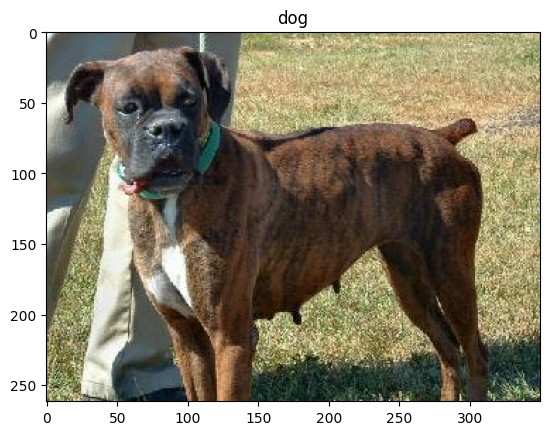

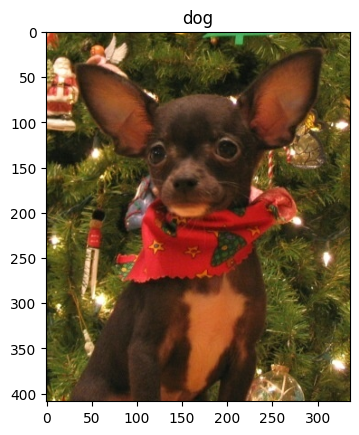

In [ ]:
get_label_name=metadata.features['label'].int2str
for image,label in raw_train.take(2):
  plt.figure()
  plt.imshow(image)
  plt.title(get_label_name(label))

In [ ]:
#Data Preprocessing
IMG_SIZE=160
def format_example(image,label):
  image=tf.cast(image,tf.float32)
  image=image/255.
  image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  return image,label
train=raw_train.map(format_example)
test=raw_test.map(format_example)
validation=raw_validation.map(format_example)

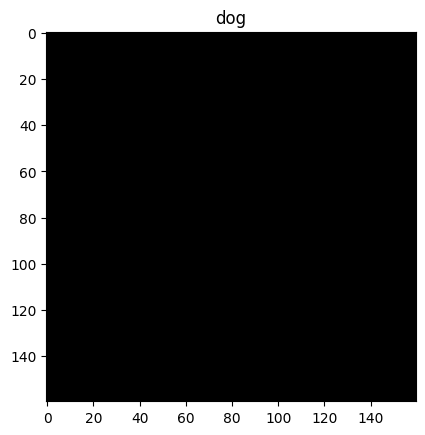

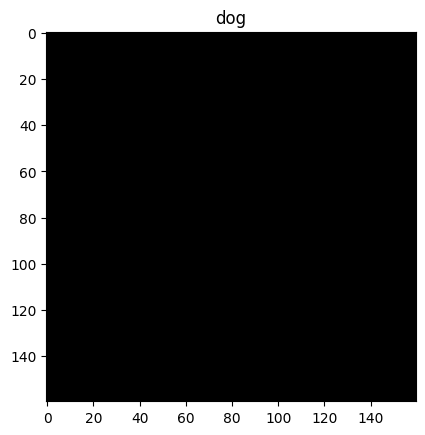

In [ ]:
get_label_name=metadata.features['label'].int2str
for image,label in train.take(2):
  plt.figure()
  plt.imshow(image)
  plt.title(get_label_name(label))

Picking a pretrained model

In [ ]:
IMG_SHAPE=(IMG_SIZE,IMG_SIZE,3)
base_model=tf.keras.applications.MobileNetV2((IMG_SHAPE),)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.summary()
train_batches=train.shuffle(1000).batch(32)
test_batches=test.batch(32)
val_batches=validation.batch(32)

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
image,label in train_batches.take(1)


ValueError: not enough values to unpack (expected 2, got 1)